In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 在VS Code的Python终端中运行
from PIL import Image
import matplotlib.pyplot as plt
def load_pic(filepath):
    # 显示图片
    img = plt.imread(filepath)
    plt.figure(figsize=(16, 12))
    plt.imshow(img)
    plt.axis('off')  # 不显示坐标轴
    plt.show()

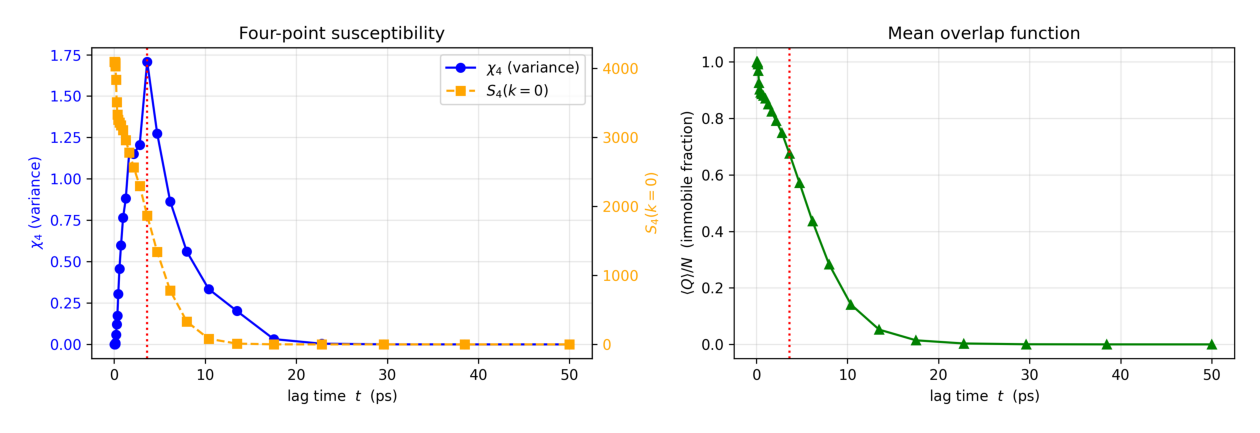

In [18]:
load_pic('/root/water/test/s4_output/chi4_vs_t.png')

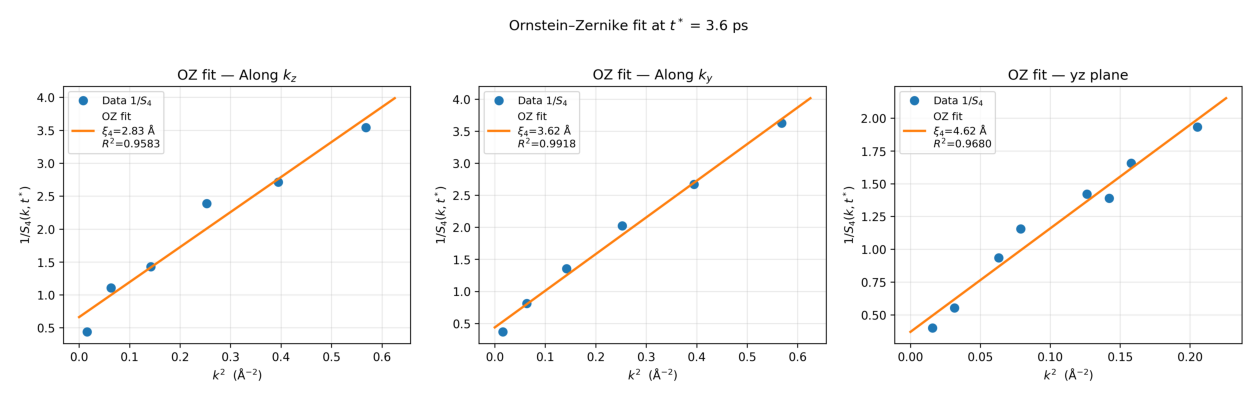

In [19]:
load_pic("/root/water/test/s4_output/OZ_fit.png")

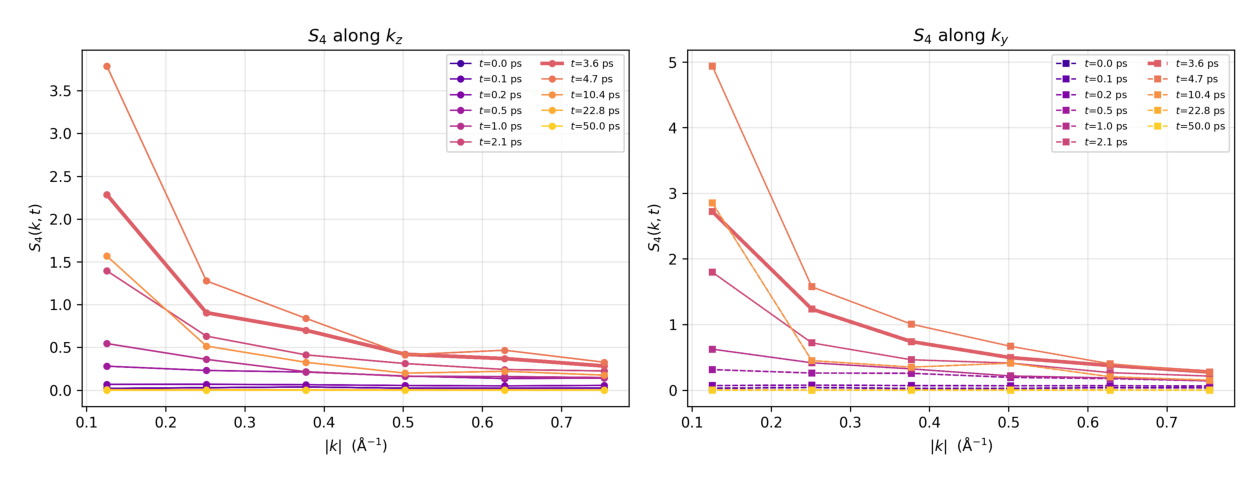

In [20]:
load_pic("/root/water/test/s4_output/S4_k_directional.png")

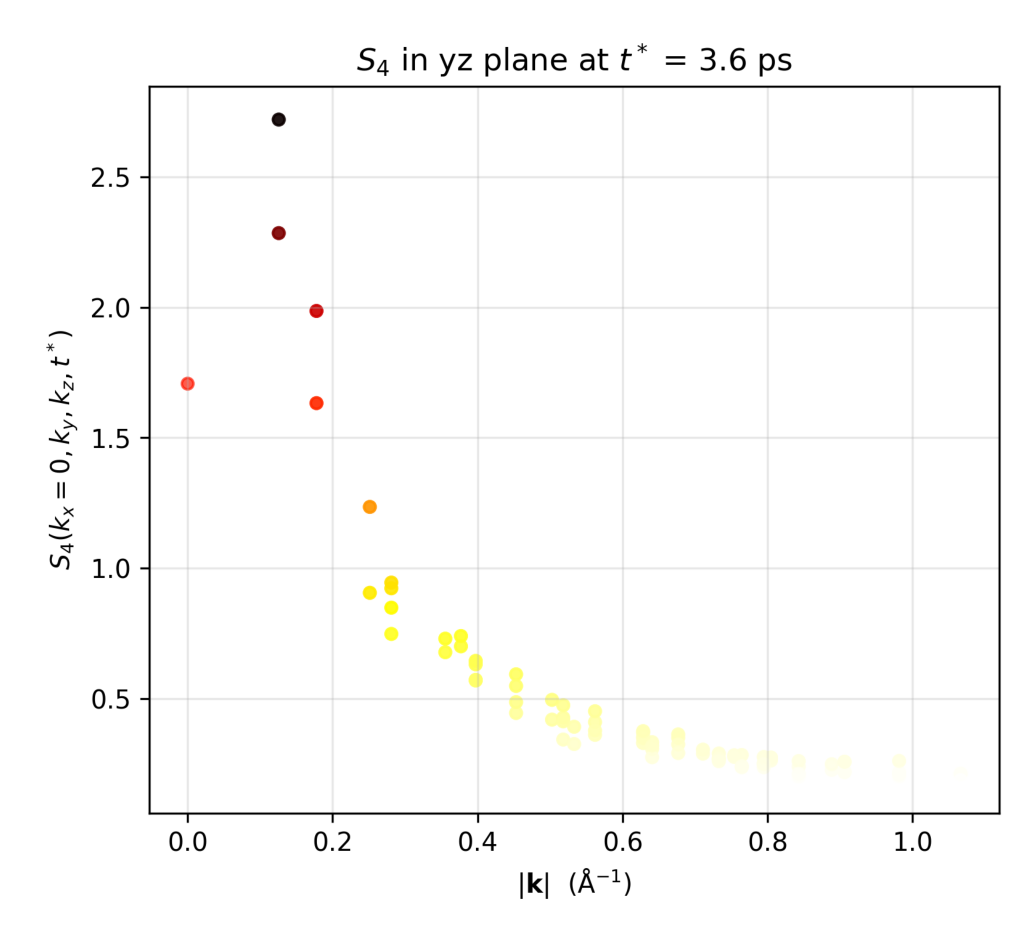

In [21]:
load_pic("/root/water/test/s4_output/S4_yz_plane.png")

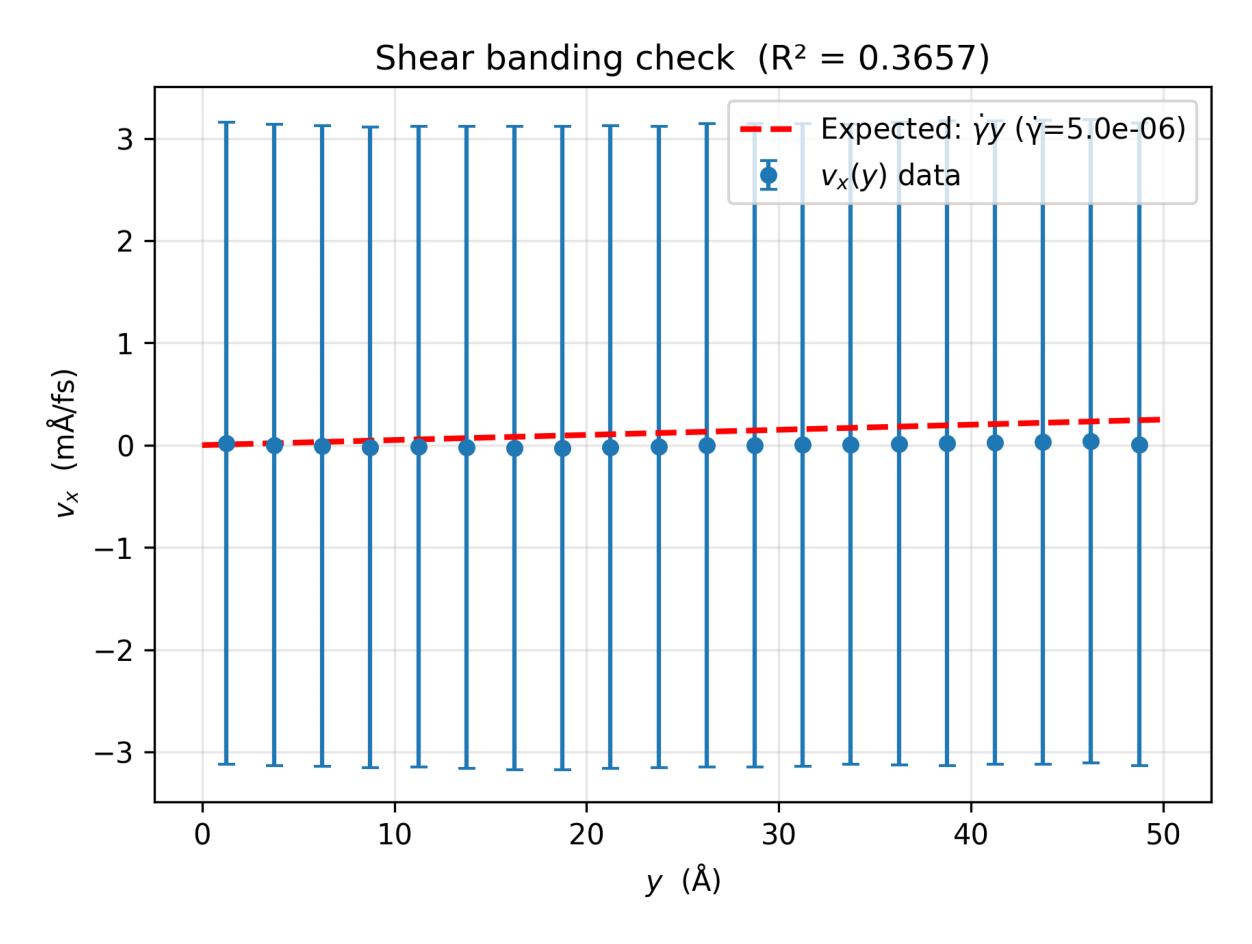

In [22]:
load_pic("/root/water/test/s4_output/shear_banding.png")

<>:53: SyntaxWarning: invalid escape sequence '\c'
<>:53: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_37746/3074719463.py:53: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Comparison of $\chi_4(t)$ and $S_4(k=0, t)$ on Separate Axes')


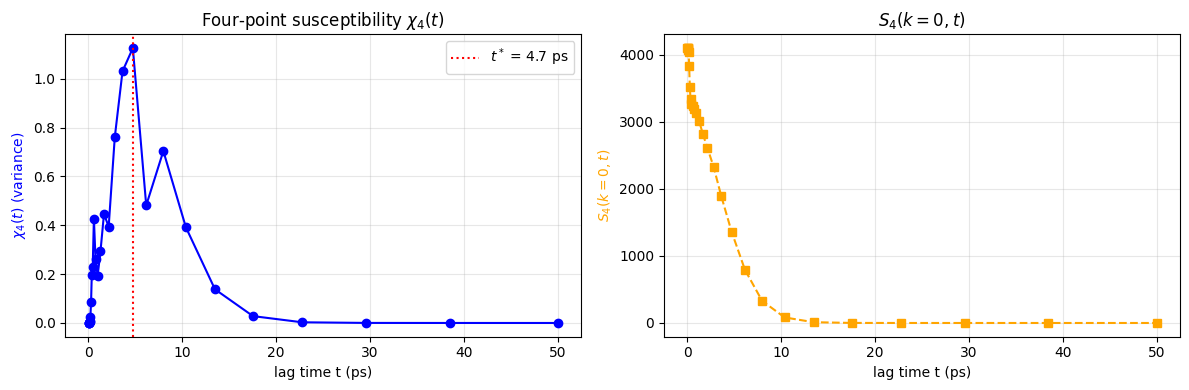

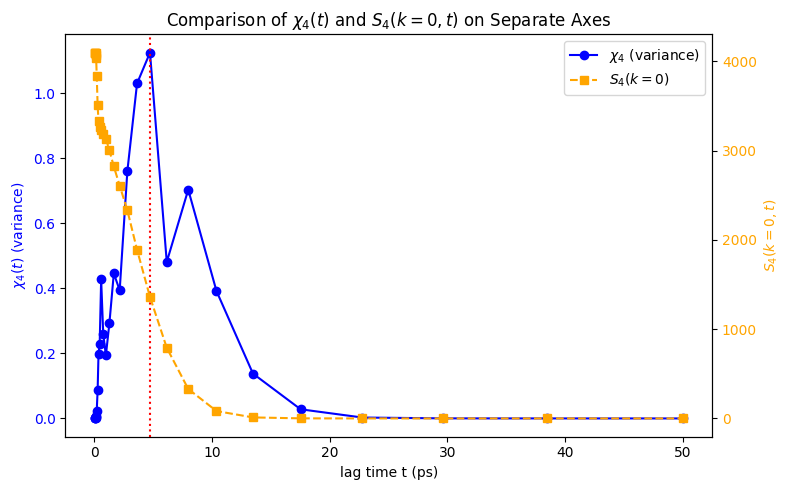

chi4_var 峰值索引: 18
chi4_var 峰值时间 t*: 4.72 ps
chi4_var 峰值大小: 1.13
此时 chi4_s4 的值: 1359.68


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 假设您已经加载了结果数据
data = np.load('/root/water/test/s4_output/s4_results.npz')
lag_times_ps = data['lag_times_fs'] / 1e3  # 转换为皮秒
chi4_var = data['chi4_var']
chi4_s4 = data['chi4_s4']

# 解决方案1：分开绘制（最清晰）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# 左图：只画 chi4_var
ax1.plot(lag_times_ps, chi4_var, 'o-', color='blue')
ax1.set_xlabel('lag time t (ps)')
ax1.set_ylabel(r'$\chi_4(t)$ (variance)', color='blue')
ax1.set_title(r'Four-point susceptibility $\chi_4(t)$')
ax1.grid(True, alpha=0.3)
# 在峰值处标记
tstar_idx = np.argmax(chi4_var)
ax1.axvline(lag_times_ps[tstar_idx], color='red', ls=':', label=f'$t^*$ = {lag_times_ps[tstar_idx]:.1f} ps')
ax1.legend()

# 右图：只画 chi4_s4
ax2.plot(lag_times_ps, chi4_s4, 's--', color='orange')
ax2.set_xlabel('lag time t (ps)')
ax2.set_ylabel(r'$S_4(k=0, t)$', color='orange')
ax2.set_title(r'$S_4(k=0, t)$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 解决方案2：使用双Y轴（在同一图中对比量级）
fig, ax1 = plt.subplots(figsize=(8,5))
color_var = 'blue'
ax1.set_xlabel('lag time t (ps)')
ax1.set_ylabel(r'$\chi_4(t)$ (variance)', color=color_var)
line1 = ax1.plot(lag_times_ps, chi4_var, 'o-', color=color_var, label=r'$\chi_4$ (variance)')
ax1.tick_params(axis='y', labelcolor=color_var)
ax1.axvline(lag_times_ps[tstar_idx], color='red', ls=':', label=f'$t^*$ = {lag_times_ps[tstar_idx]:.1f} ps')

ax2 = ax1.twinx()
color_s4 = 'orange'
ax2.set_ylabel(r'$S_4(k=0, t)$', color=color_s4)
line2 = ax2.plot(lag_times_ps, chi4_s4, 's--', color=color_s4, label=r'$S_4(k=0)$')
ax2.tick_params(axis='y', labelcolor=color_s4)

# 合并图例
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Comparison of $\chi_4(t)$ and $S_4(k=0, t)$ on Separate Axes')
fig.tight_layout()
plt.show()

# 打印峰值信息进行确认
print(f"chi4_var 峰值索引: {tstar_idx}")
print(f"chi4_var 峰值时间 t*: {lag_times_ps[tstar_idx]:.2f} ps")
print(f"chi4_var 峰值大小: {chi4_var[tstar_idx]:.2f}")
print(f"此时 chi4_s4 的值: {chi4_s4[tstar_idx]:.2f}")

# orientation analysis？

In [3]:
from water.tools.water_orient import (
    body_frames, dipole_vectors, tetrahedral_q,
    detect_hbonds, compute_zeta, coarse_grain_zeta,
    identify_donor_arm_jumps, classify_zeta_change_cause,
    )
import MDAnalysis as mda
from MDAnalysis.lib.distances import apply_PBC, minimize_vectors
import numpy as np
import matplotlib.pyplot as plt

In [2]:
u = mda.Universe("/root/water/TIP4P/Ice/tip4p-ice.data","/root/water/TIP4P/Ice/225/dump_225_test.lammpstrj", format="LAMMPSDUMP",dt=0.2)

In [4]:
waters = []

for res in u.residues:
    O = res.atoms.select_atoms("type 1")[0]
    Hs = O.bonded_atoms
    if len(Hs) == 2:
        waters.append((O.index, Hs[0].index, Hs[1].index))

O_idx  = np.array([w[0] for w in waters])
H1_idx = np.array([w[1] for w in waters])
H2_idx = np.array([w[2] for w in waters])

In [28]:
prev_pos = None
prev_orient = None

trans = []
rots = []

for ts in u.trajectory:
    pos = u.atoms.positions

    O = pos[O_idx]
    H1 = pos[H1_idx]
    H2 = pos[H2_idx]

    current_pos = O.copy()
    orient = (H1 + H2) / 2 - O
    orient /= np.linalg.norm(orient, axis=1, keepdims=True)

    if prev_pos is not None:
        disp = current_pos - prev_pos
        disp = minimize_vectors(disp, box=ts.dimensions)
        distances = np.linalg.norm(disp, axis=1)

        if prev_orient is not None:
            cos_angles = np.sum(prev_orient * orient, axis=1)
            cos_angles = np.clip(cos_angles, -1.0, 1.0)
            angles = np.arccos(cos_angles) * 360 / (2 * np.pi)

        trans.append(distances)
        rots.append(angles)

    prev_pos = current_pos
    prev_orient = orient

In [29]:
# 时间序列（从0开始）
time_series = np.arange(len(trans)) * dt

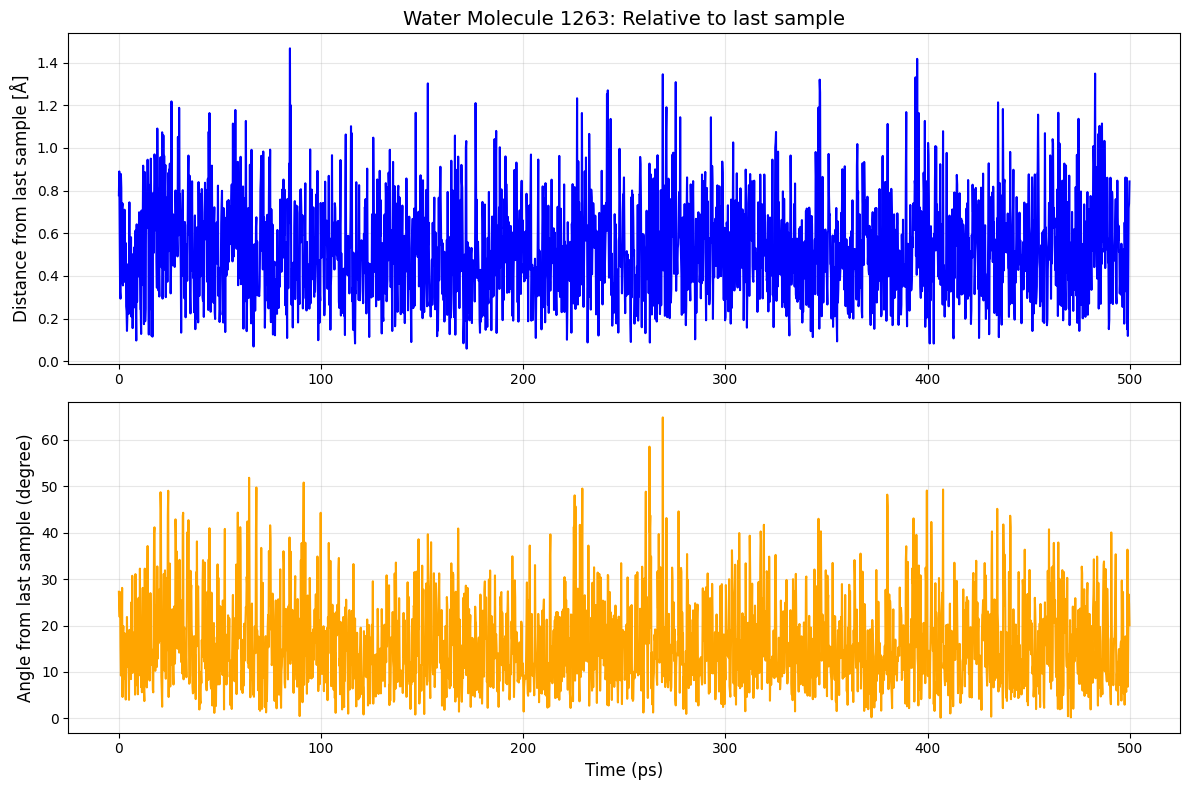

In [52]:
# 绘制结果
i = 1263  # molecule index

dist_series = [frame[i] for frame in trans]
angle_series = [frame[i] for frame in rots]

# 创建图形
plt.figure(figsize=(12, 8))

# 第一个子图：相对于初始位置的位移
plt.subplot(2, 1, 1)
plt.plot(time_series, dist_series, linewidth=1.5, color='blue')
plt.ylabel("Distance from last sample [Å]", fontsize=12)
plt.title(f"Water Molecule {i}: Relative to last sample", fontsize=14)
plt.grid(True, alpha=0.3)

# 第二个子图：相对于初始方向的角度
plt.subplot(2, 1, 2)
plt.plot(time_series, angle_series, linewidth=1.5, color='orange')
plt.ylabel("Angle from last sample (degree)", fontsize=12)
plt.xlabel("Time (ps)", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_65702/2791918974.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


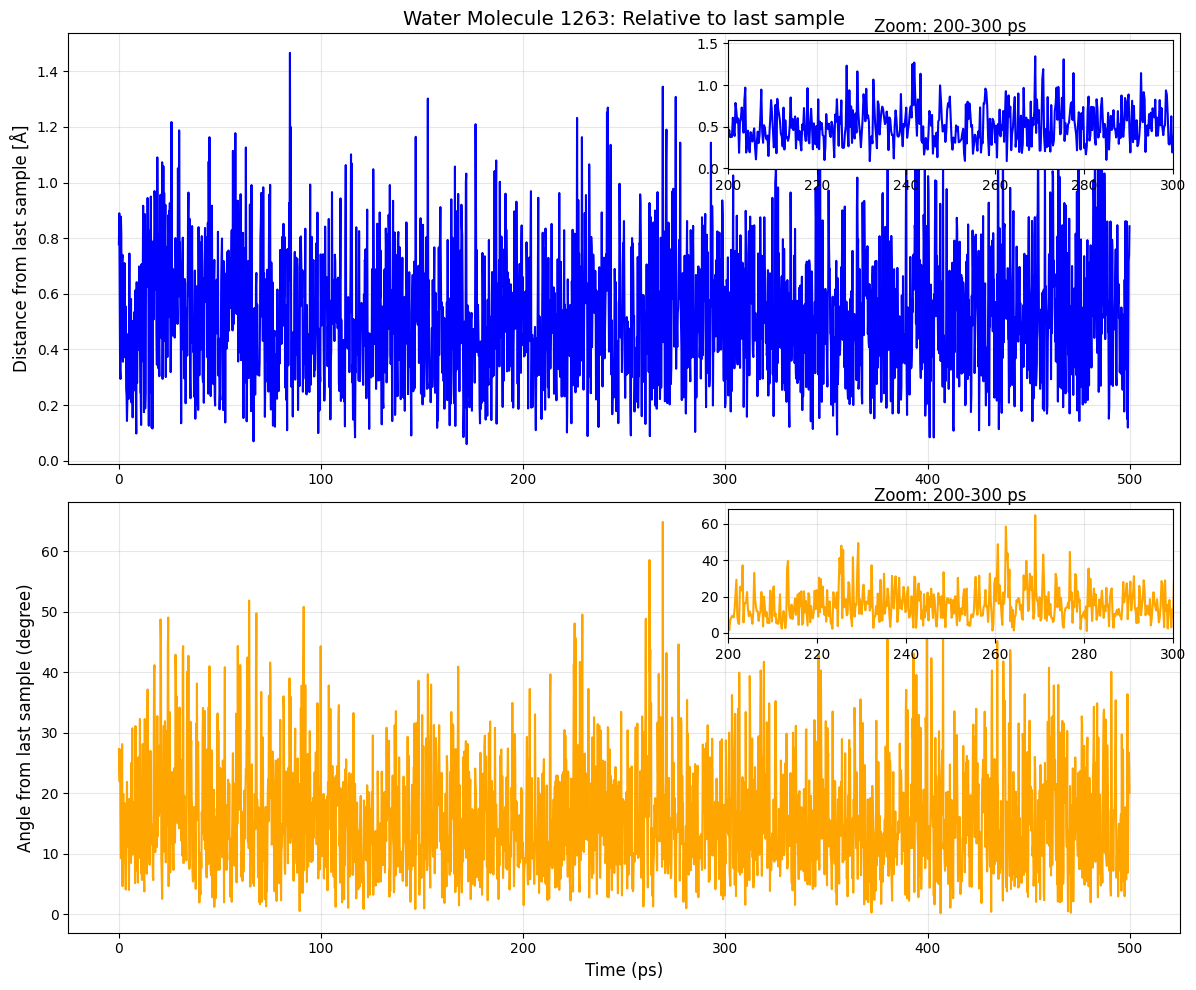

In [53]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 创建图形
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 第一个子图：位移
ax1.plot(time_series, dist_series, linewidth=1.5, color='blue')
ax1.set_ylabel("Distance from last sample [Å]", fontsize=12)
ax1.set_title(f"Water Molecule {i}: Relative to last sample", fontsize=14)
ax1.grid(True, alpha=0.3)

# 添加位移图的缩放区域
ax1_inset = inset_axes(ax1, width="40%", height="30%", loc='upper right')
ax1_inset.plot(time_series, dist_series, linewidth=1.5, color='blue')
ax1_inset.set_xlim(200, 300)
ax1_inset.set_title('Zoom: 200-300 ps')
ax1_inset.grid(True, alpha=0.3)

# 第二个子图：角度
ax2.plot(time_series, angle_series, linewidth=1.5, color='orange')
ax2.set_ylabel("Angle from last sample (degree)", fontsize=12)
ax2.set_xlabel("Time (ps)", fontsize=12)
ax2.grid(True, alpha=0.3)

# 添加角度图的缩放区域
ax2_inset = inset_axes(ax2, width="40%", height="30%", loc='upper right')
ax2_inset.plot(time_series, angle_series, linewidth=1.5, color='orange')
ax2_inset.set_xlim(200, 300)
ax2_inset.set_title('Zoom: 200-300 ps')
ax2_inset.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
import numpy as np
from MDAnalysis.lib.distances import minimize_vectors
import matplotlib.pyplot as plt

# 初始化变量
initial_pos = None
initial_orient = None
initial_frame_set = False

initial_trans = []  # 存储相对于初始位置的位移
initial_rots = []   # 存储相对于初始位置的角度变化

for ts in u.trajectory:
    pos = u.atoms.positions

    O = pos[O_idx]
    H1 = pos[H1_idx]
    H2 = pos[H2_idx]

    current_pos = O.copy()
    orient = (H1 + H2) / 2 - O
    orient /= np.linalg.norm(orient, axis=1, keepdims=True)
    
    # 如果是第一帧，保存初始位置和方向
    if not initial_frame_set:
        initial_pos = current_pos.copy()
        initial_orient = orient.copy()
        initial_frame_set = True
        
        # 第一帧相对于自身，位移和角度都为0
        initial_trans.append(np.zeros_like(current_pos[:, 0]))  # 位移为0
        initial_rots.append(np.zeros_like(current_pos[:, 0]))   # 角度为0
    else:
        # 计算相对于初始位置的位移（考虑PBC）
        disp = current_pos - initial_pos
        disp = minimize_vectors(disp, box=ts.dimensions)
        distances = np.linalg.norm(disp, axis=1)
        
        # 计算相对于初始方向的角度
        cos_angles = np.sum(initial_orient * orient, axis=1)
        cos_angles = np.clip(cos_angles, -1.0, 1.0)
        angles = np.arccos(cos_angles) * 360 / (2*np.pi)
        
        initial_trans.append(distances)
        initial_rots.append(angles)

In [46]:
dt = u.trajectory.dt  # 时间步长（皮秒或纳秒，根据你的轨迹单位）
time_per_frame = dt  # 每帧的时间间隔

# 创建时间序列
# trans 和 rots 的长度是 n_frames-1，因为是从第二帧开始计算的
initial_time_series = np.arange(len(trans)) * time_per_frame  # 从0开始的时间序列

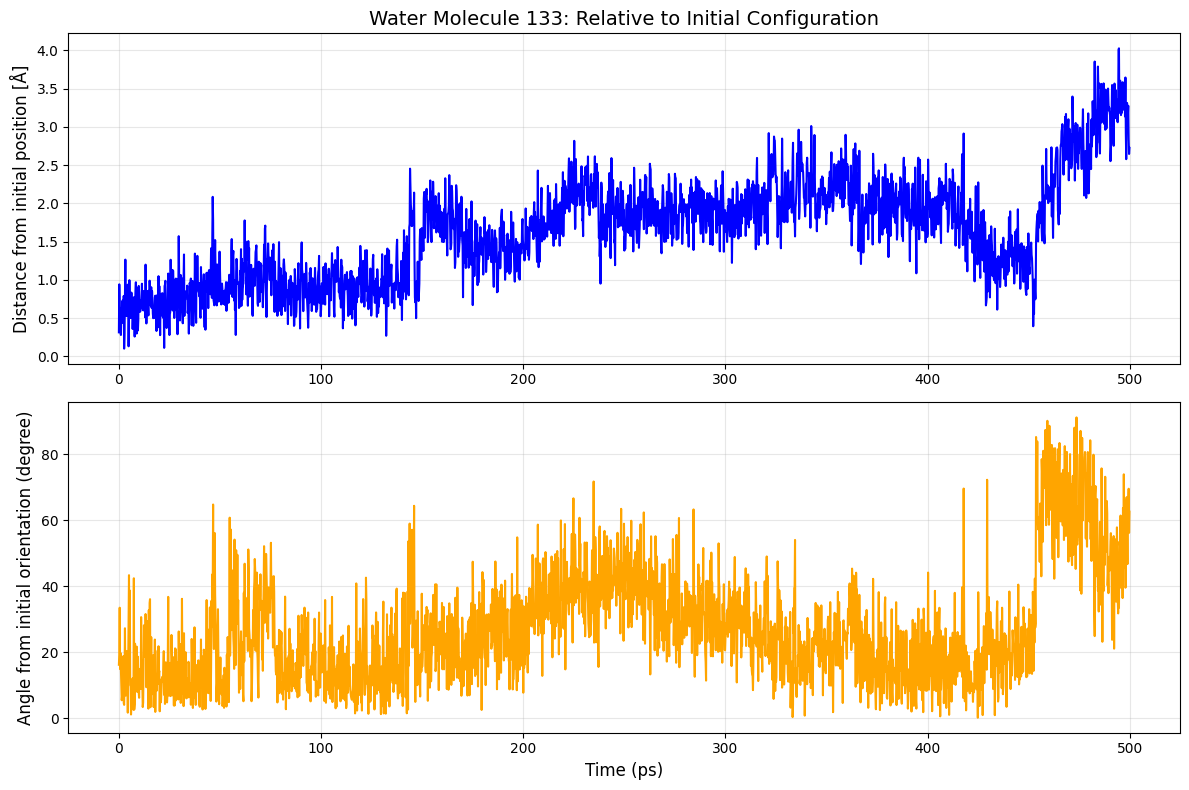

In [56]:
# 绘制结果
i = 133  # molecule index

initial_dist_series = [frame[i] for frame in initial_trans]
initial_angle_series = [frame[i] for frame in initial_rots]

# 创建图形
plt.figure(figsize=(12, 8))

# 第一个子图：相对于初始位置的位移
plt.subplot(2, 1, 1)
plt.plot(initial_time_series, initial_dist_series[1:], linewidth=1.5, color='blue')
plt.ylabel("Distance from initial position [Å]", fontsize=12)
plt.title(f"Water Molecule {i}: Relative to Initial Configuration", fontsize=14)
plt.grid(True, alpha=0.3)

# 第二个子图：相对于初始方向的角度
plt.subplot(2, 1, 2)
plt.plot(initial_time_series, initial_angle_series[1:], linewidth=1.5, color='orange')
plt.ylabel("Angle from initial orientation (degree)", fontsize=12)
plt.xlabel("Time (ps)", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_65702/109723529.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


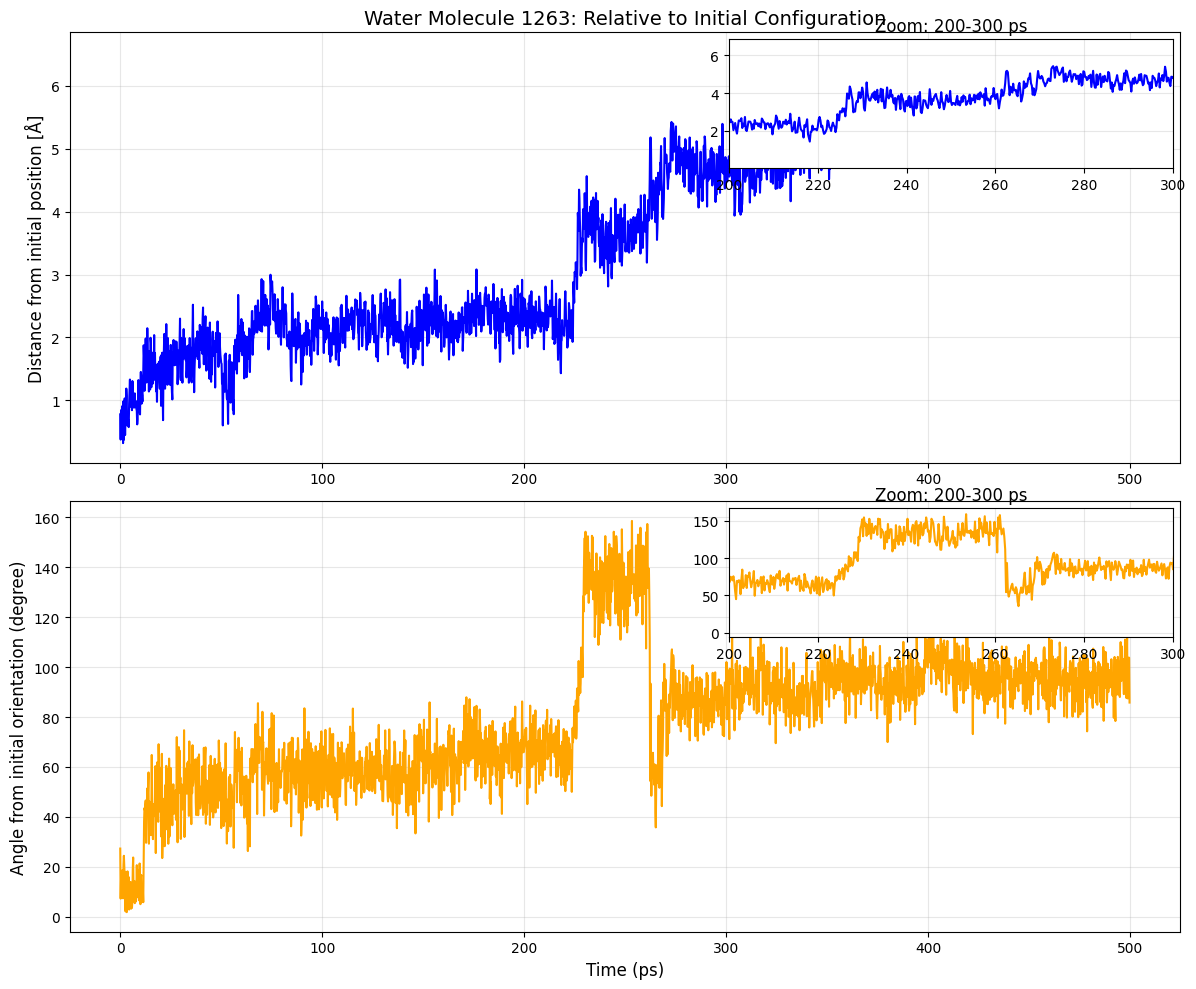

In [51]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 创建图形
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 第一个子图：位移
ax1.plot(initial_time_series, initial_dist_series[1:], linewidth=1.5, color='blue')
ax1.set_ylabel("Distance from initial position [Å]", fontsize=12)
ax1.set_title(f"Water Molecule {i}: Relative to Initial Configuration", fontsize=14)
ax1.grid(True, alpha=0.3)

# 添加位移图的缩放区域
ax1_inset = inset_axes(ax1, width="40%", height="30%", loc='upper right')
ax1_inset.plot(initial_time_series, initial_dist_series[1:], linewidth=1.5, color='blue')
ax1_inset.set_xlim(200, 300)
ax1_inset.set_title('Zoom: 200-300 ps')
ax1_inset.grid(True, alpha=0.3)

# 第二个子图：角度
ax2.plot(initial_time_series, initial_angle_series[1:], linewidth=1.5, color='orange')
ax2.set_ylabel("Angle from initial orientation (degree)", fontsize=12)
ax2.set_xlabel("Time (ps)", fontsize=12)
ax2.grid(True, alpha=0.3)

# 添加角度图的缩放区域
ax2_inset = inset_axes(ax2, width="40%", height="30%", loc='upper right')
ax2_inset.plot(initial_time_series, initial_angle_series[1:], linewidth=1.5, color='orange')
ax2_inset.set_xlim(200, 300)
ax2_inset.set_title('Zoom: 200-300 ps')
ax2_inset.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
isf_equili = pd.read_hdf("/root/water/TIP4P/Ice/test/h5/isf_results.h5",key='equili')
isf_shear = pd.read_hdf("/root/water/TIP4P/Ice/test/h5/isf_results.h5",key='5e-6')

In [13]:
relative_data= pd.read_csv("/root/Default Dataset.csv", names=['time_ps','ISF'])

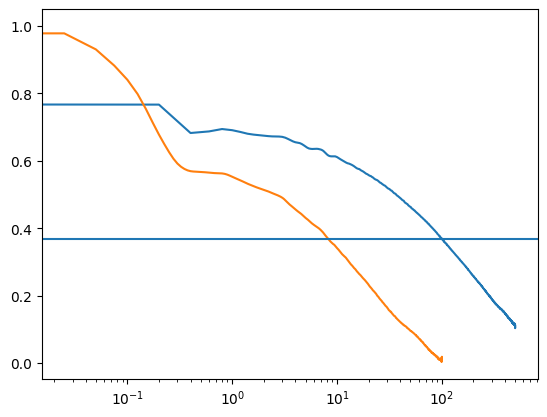

In [4]:
plt.plot(isf_equili['time_ps'], isf_equili['ISF'])
plt.plot(isf_shear['time_ps'], isf_shear['ISF'])
plt.axhline(1/np.e)
plt.xscale('log')
plt.show()